[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/seap-udea/MontuPython/blob/main/examples/MontuPython-Montunctions.ipynb)

<p align="left"><img src="https://github.com/seap-udea/MontuPython/raw/main/montu/data/montu-python-logo-complete.webp" width="300" /></p>

# Montunctions

In this notebook we calculate the conjunction between Mars and Aldebaran during the so-called stationary phases of the planet. This notebook and the derived plots were used in the context of the work "ESTUDIO DE LAS ORIENTACIONES
ASTRONÓMICAS Y PAISAJÍSTICAS DE LOS MONUMENTOS DE SENENMUT EN LA NECRÓPOLIS TEBANA" presented as Ph. D. Thesis by Francisco Vivas Fernández (2023).

If you are running this script in Google Colab you need first to install the package and create a directory for saving plots:

In [1]:
%pip install -Uq montu
!mkdir -p ./gallery/

Note: you may need to restart the kernel to use updated packages.


## Goals of this notebook

The goal of this notebook is to determine the stable positions of mars across ancient Egypt history and check when this *marsticies* happened close to the winter solstice and in the Taurus constellation.

### Loading tools

We need to load the packages and the required data for it (star database, planet position database, etc.):

In [2]:
# Montu packages and data
%matplotlib inline
import montu
from montu import D2H, PRINTDF, TABLEDF, DEG, RAD

# Other libraries required
import pandas as pd
import copy
import matplotlib.pyplot as plt
import numpy as np

# Load allstars
allstars = montu.Stars()

# Autoreload refreshes local copies of montu when you edit the source.
# Not available in Google Colab (Python 3.12+): IPython autoreload still imports removed module `imp`.
# Uncomment only in a local Jupyter notebook:
# %load_ext autoreload
# %autoreload 2

MontuPython version 0.21.3. 𓋹 𓍘 𓋴 𓎛 𓂡 𓁘 (ii-ti m Htp, HkAx Hn'-k)
Loading stellar catalogue montu_stellar_catalogue_v38.csv


### *Marstices*

Lets set observing conditions and initial time of exploration:

In [3]:
Tebas = montu.Observer(lon=33,lat=24,height=0)

Our target body:

In [4]:
mars = montu.Planet('Mars')

Now let's predict all the Marstices:

In [5]:
marstices = pd.DataFrame()
i = 0

# Range of years
# initial_year = -2500
initial_year = -2000
final_year = -500

mars.reset_store()
mtime = montu.Time(f'{initial_year}-01-01 00:00:00.00',scale='utc',calendar='proleptic')

marstices = []
for _ in montu.WHILE_TRUE():
    jed1,jed2 = mars.next_planesticies(mtime)
    mtime1 = montu.Time(jed1,format='jd',full=True)
    mtime2 = montu.Time(jed2,format='jd',full=True)
    
    # Stopping condition
    if mtime2.readable.year > final_year:
        break
    
    marstices += [pd.DataFrame(dict(
        datepro = [mtime1.readable.datepro,mtime2.readable.datepro],
        datemix = [mtime1.readable.datemix,mtime2.readable.datemix],
        type = ['first','second'],
        jed = [mtime1.jed,mtime2.jed],
    ))]

    mtime = mtime + 2*montu.YEAR
    i += 1

marstices = pd.concat(marstices)
marstices.drop_duplicates(inplace=True)
marstices.reset_index(drop=True,inplace=True)

0it [00:00, ?it/s]

468it [00:00, 4672.66it/s]

750it [00:00, 4703.58it/s]

In [6]:
marstices

,datepro,datemix,type,jed
0,-2001-09-21 12:52:37.202864,-2001-10-08 12:52:52,first,9.904730e+05
1,-2001-12-09 02:02:01.397744,-2001-12-26 02:02:02,second,9.905516e+05
2,-1999-10-25 10:48:04.207680,-1999-11-11 10:48:48,first,9.912380e+05
3,-1998-01-14 00:58:12.599040,-1998-01-31 00:58:58,second,9.913185e+05
4,-1997-11-30 04:28:27.698864,-1997-12-17 04:28:28,first,9.920037e+05
...,...,...,...,...
1401,-506-09-04 21:49:24.496304,-506-09-10 21:49:49,second,1.536494e+06
1402,-504-08-30 13:09:38.597744,-504-09-05 13:09:09,first,1.537220e+06
1403,-504-11-10 12:33:59.497920,-504-11-16 12:33:33,second,1.537292e+06
1404,-502-10-10 16:51:06.001920,-502-10-16 16:51:51,first,1.537991e+06


Now we want to add to this information other relevant astronomical information:

1. Position of mars in the sky
2. Date of occurrence of winter solstices
3. Angular distance of Mars to Aldebaran

Position of Mars in the sky:

In [7]:
mars.reset_store()
for index in montu.PROGRESS(marstices.index):
    marstice = marstices.loc[index]

    # Get MonTime object
    mtime = montu.Time(marstice.jed,format='jd')

    # Calculate Mars position and store it
    mars.conditions_in_sky(mtime,Tebas,store=1)
mars.tabulate_store()

  0%|                                                                                                                   | 0/1406 [00:00<?, ?it/s]

 35%|████████████████████████████████████▍                                                                  | 498/1406 [00:00<00:00, 4977.86it/s]

 72%|█████████████████████████████████████████████████████████████████████████▋                            | 1016/1406 [00:00<00:00, 5094.65it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1406/1406 [00:00<00:00, 5056.62it/s]

Positions are stored in a separate dataframe:

In [8]:
mars_marstices = copy.deepcopy(mars.position)
mars_marstices['Vmag'] = mars.condition.Vmag
mars_marstices

,tt,jed,Name,RAJ2000,DecJ2000,RAEpoch,DecEpoch,RAGeo,DecGeo,el,az,Vmag
0,-126236570942,9.904730e+05,Mars,7.026757,23.322960,3.073795,17.836212,3.073797,17.838371,-48.159613,359.135417,-0.67
1,-126229784378,9.905516e+05,Mars,5.632474,26.221096,1.774031,13.756077,1.774203,13.757510,-15.035019,292.899084,-0.43
2,-126170482464,9.912380e+05,Mars,9.479705,17.711436,5.517021,26.057501,5.517134,26.059545,-29.869770,324.116464,-0.39
3,-126163519480,9.913185e+05,Mars,8.165966,24.253872,4.077912,24.892369,4.078105,24.893611,2.560390,296.310081,-0.35
4,-126104322889,9.920037e+05,Mars,11.642726,6.391030,8.006254,24.704358,8.006401,24.704688,46.465886,281.282326,-0.40
...,...,...,...,...,...,...,...,...,...,...,...,...
1401,-79060353742,1.536494e+06,Mars,23.006199,-11.674151,20.715271,-23.418157,20.715457,-23.414697,32.736253,216.581241,-1.98
1402,-78997658558,1.537220e+06,Mars,3.772105,17.271194,1.514450,6.586747,1.514421,6.588904,-58.778088,12.376669,-1.44
1403,-78991439897,1.537292e+06,Mars,2.614838,15.741818,0.423314,2.972830,0.423091,2.974326,-2.157872,85.168320,-1.02
1404,-78931030900,1.537991e+06,Mars,6.919953,23.751538,4.395169,22.487648,4.394980,22.489512,-16.465913,55.376534,-0.76


Compute the date of the previous and next winter solstice, and the days elapsed to the closest one:

In [9]:
# Loop on marstices
for index in montu.PROGRESS(marstices.index):
    marstice = marstices.loc[index]

    # Get MonTime object
    mtime = montu.Time(marstice.jed,format='jd')

    # Calculate next and previous solstices
    prev_seasons = montu.Sun.previous_seasons(at=mtime)
    next_seasons = montu.Sun.next_seasons(at=mtime)
    
    # Get the closest solstice
    closest_solstice = min(abs(mtime.jed - prev_seasons[3]),
                           abs(mtime.jed - next_seasons[3]))

    # Add winter solstice to DataFrame
    marstices.loc[index,'closest_solstice'] = closest_solstice

marstices
    

  0%|                                                                                                                   | 0/1406 [00:00<?, ?it/s]

 21%|█████████████████████▌                                                                                 | 294/1406 [00:00<00:00, 2932.64it/s]

 42%|███████████████████████████████████████████▎                                                           | 592/1406 [00:00<00:00, 2959.15it/s]

 63%|█████████████████████████████████████████████████████████████████                                      | 888/1406 [00:00<00:00, 2899.30it/s]

 84%|█████████████████████████████████████████████████████████████████████████████████████▉                | 1185/1406 [00:00<00:00, 2924.29it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1406/1406 [00:00<00:00, 2945.05it/s]

,datepro,datemix,type,jed,closest_solstice
0,-2001-09-21 12:52:37.202864,-2001-10-08 12:52:52,first,9.904730e+05,89.858280
1,-2001-12-09 02:02:01.397744,-2001-12-26 02:02:02,second,9.905516e+05,11.310084
2,-1999-10-25 10:48:04.207680,-1999-11-11 10:48:48,first,9.912380e+05,55.435827
3,-1998-01-14 00:58:12.599040,-1998-01-31 00:58:58,second,9.913185e+05,25.154548
4,-1997-11-30 04:28:27.698864,-1997-12-17 04:28:28,first,9.920037e+05,20.186209
...,...,...,...,...,...
1401,-506-09-04 21:49:24.496304,-506-09-10 21:49:49,second,1.536494e+06,106.888026
1402,-504-08-30 13:09:38.597744,-504-09-05 13:09:09,first,1.537220e+06,111.737487
1403,-504-11-10 12:33:59.497920,-504-11-16 12:33:33,second,1.537292e+06,39.762245
1404,-502-10-10 16:51:06.001920,-502-10-16 16:51:51,first,1.537991e+06,71.062716


In [10]:
marstices.iloc[:10]

,datepro,datemix,type,jed,closest_solstice
0,-2001-09-21 12:52:37.202864,-2001-10-08 12:52:52,first,990473.036542,89.858280
1,-2001-12-09 02:02:01.397744,-2001-12-26 02:02:02,second,990551.584738,11.310084
2,-1999-10-25 10:48:04.207680,-1999-11-11 10:48:48,first,991237.950049,55.435827
3,-1998-01-14 00:58:12.599040,-1998-01-31 00:58:58,second,991318.540424,25.154548
4,-1997-11-30 04:28:27.698864,-1997-12-17 04:28:28,first,992003.686432,20.186209
5,-1996-02-18 07:27:10.992944,-1996-03-06 07:27:27,second,992083.810544,59.937904
6,-1994-01-10 01:13:45.304320,-1994-01-27 01:13:13,first,992775.551219,21.198671
7,-1994-03-27 17:44:02.307824,-1994-04-13 17:44:44,second,992852.238916,97.886368
8,-1992-03-07 22:03:49.904640,-1992-03-24 22:03:03,first,993563.419328,78.589665
9,-1992-05-14 16:51:47.404800,-1992-05-31 16:51:51,second,993631.202632,146.372970


Now we want to compute the angular distance to Aldebaran. For this purpose, we need to get the information about the star from the database:

In [11]:
aldebaran = allstars.get_stars(ProperName='Aldebaran')
aldebaran

1 star(s):
|    |   MN |    HD |   HR |   HIP | Gl        | Name      | OtherDesignations                                                                     | ProperName   | Bayer   | Flamsteed   | Constellation   |   RAJ2000 |   DecJ2000 |   GalLonJ2000 |   GalLatJ2000 |   pmRA |   pmDec |   RadVel |   Distance |   Vmag |   Vmag_min |   Vmag_max |   B-V | SpType   |   Luminosity |   XJ2000 |   YJ2000 |   ZJ2000 |   VXJ2000 |   VYJ2000 |   VZJ2000 |   Primary | MultipleID   |   IsMultiple |   IsVariable |
|----|------|-------|------|-------|-----------|-----------|---------------------------------------------------------------------------------------|--------------|---------|-------------|-----------------|-----------|------------|---------------|---------------|--------|---------|----------|------------|--------|------------|------------|-------|----------|--------------|----------|----------|----------|-----------|-----------|-----------|-----------|--------------|--------------|---

Now we will compute for each marstice, the angular distance to Aldebaran:

In [12]:
# Loop on marstices
for index in montu.PROGRESS(marstices.index):

    # Get marstice information and location of mars
    marstice = marstices.loc[index]
    mars_location = mars_marstices.loc[index]

    # Propagate aldebaran to epoch
    mtime = montu.Time(marstice.jed,format='jd')
    aldebaran.where_in_space(at=mtime,inplace=True)

    # Compute angular distance
    aldebaran_angdist = montu.Util.haversine_distance(
        mars_location.DecJ2000*DEG,15*mars_location.RAJ2000*DEG,
        aldebaran.scalar('DecJ2000t')*DEG,15*aldebaran.scalar('RAJ2000t')*DEG
    )*RAD    
    
    # uncomment to check
    """
    print(marstice.jed,marstice.datemix)
    print(D2H(mars_location.DecJ2000),D2H(mars_location.RAJ2000))
    print(D2H(aldebaran.scalar('DecJ2000t')),D2H(aldebaran.scalar('RAJ2000t')))
    print(D2H(aldebaran_angdist))
    break
    #"""

    # Angular distance
    marstices.loc[index,'aldebaran_angdist'] = aldebaran_angdist

marstices

  0%|                                                                                                                   | 0/1406 [00:00<?, ?it/s]

 13%|█████████████▊                                                                                         | 189/1406 [00:00<00:00, 1889.34it/s]

 28%|████████████████████████████▍                                                                          | 388/1406 [00:00<00:00, 1944.65it/s]

 41%|██████████████████████████████████████████▋                                                            | 583/1406 [00:00<00:00, 1928.26it/s]

 56%|█████████████████████████████████████████████████████████▏                                             | 781/1406 [00:00<00:00, 1945.67it/s]

 70%|███████████████████████████████████████████████████████████████████████▉                               | 982/1406 [00:00<00:00, 1967.13it/s]

 84%|█████████████████████████████████████████████████████████████████████████████████████▌                | 1179/1406 [00:00<00:00, 1941.44it/s]

 98%|███████████████████████████████████████████████████████████████████████████████████████████████████▉  | 1377/1406 [00:00<00:00, 1953.58it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 1406/1406 [00:00<00:00, 1945.49it/s]

,datepro,datemix,type,jed,closest_solstice,aldebaran_angdist
0,-2001-09-21 12:52:37.202864,-2001-10-08 12:52:52,first,9.904730e+05,89.858280,34.820239
1,-2001-12-09 02:02:01.397744,-2001-12-26 02:02:02,second,9.905516e+05,11.310084,17.306733
2,-1999-10-25 10:48:04.207680,-1999-11-11 10:48:48,first,9.912380e+05,55.435827,69.517868
3,-1998-01-14 00:58:12.599040,-1998-01-31 00:58:58,second,9.913185e+05,25.154548,50.461178
4,-1997-11-30 04:28:27.698864,-1997-12-17 04:28:28,first,9.920037e+05,20.186209,103.062474
...,...,...,...,...,...,...
1401,-506-09-04 21:49:24.496304,-506-09-10 21:49:49,second,1.536494e+06,106.888026,87.553815
1402,-504-08-30 13:09:38.597744,-504-09-05 13:09:09,first,1.537220e+06,111.737487,11.832605
1403,-504-11-10 12:33:59.497920,-504-11-16 12:33:33,second,1.537292e+06,39.762245,28.523663
1404,-502-10-10 16:51:06.001920,-502-10-16 16:51:51,first,1.537991e+06,71.062716,33.393108


In [13]:
marstices.aldebaran_angdist.describe()

count    1406.000000
mean       84.160880
std        50.362013
min         3.311582
25%        39.914786
50%        81.051776
75%       126.587916
max       176.560331
Name: aldebaran_angdist, dtype: float64

Now we will mark the marstices according to closest solstice and aldebaran angular distance:

In [14]:
max_days_to_solstice = 15 # days
max_aldebaran_angdist = 15 # degrees
max_aldebaran_conjunc = 5 # degrees

marstices['close_solstice'] = False
marstices['close_aldebaran'] = False
marstices['conj_aldebaran'] = False
marstices['montunctions'] = False

cond_solstices = (marstices['closest_solstice']<=max_days_to_solstice)
marstices.loc[cond_solstices,'close_solstice'] = True
print("Number of marstices close to solstices: ",cond_solstices.sum())

cond_aldebaran = (marstices['aldebaran_angdist']<=max_aldebaran_angdist)
marstices.loc[cond_aldebaran,'close_aldebaran'] = True
print("Number of marstices close to Aldebaran: ",cond_aldebaran.sum())

cond_montunctions = (cond_solstices) & (cond_aldebaran)
marstices.loc[cond_montunctions,'montunctions'] = True
print("Number of Montunctions: ",cond_montunctions.sum())

cond_conjunction = (marstices['aldebaran_angdist']<=max_aldebaran_conjunc)
marstices.loc[cond_conjunction,'conj_aldebaran'] = True
print("Number of close conjunctions: ",cond_conjunction.sum())

Number of marstices close to solstices:  146
Number of marstices close to Aldebaran:  121
Number of Montunctions:  24
Number of close conjunctions:  15


These are the dates:

In [15]:
mtime_start = montu.Time('bce1050-01-01 00:00:00.00')+(-10*montu.YEAR)
mtime_end = montu.Time('bce1050-01-01 00:00:00.00')+10*montu.YEAR
cond = (marstices.jed>=mtime_start.jed) & (marstices.jed<=mtime_end.jed)
marstices[cond]

,datepro,datemix,type,jed,closest_solstice,aldebaran_angdist,close_solstice,close_aldebaran,conj_aldebaran,montunctions
882,-1059-06-03 00:48:55.802880,-1059-06-13 00:48:48,first,1.334422e+06,164.897449,101.821584,False,False,False,False
883,-1059-08-02 10:56:53.096656,-1059-08-12 10:56:56,second,1.334482e+06,139.920916,111.666625,False,False,False,False
884,-1057-08-07 06:00:19.500480,-1057-08-17 06:00:00,first,1.335217e+06,135.620189,29.896782,False,False,False,False
885,-1057-10-15 18:54:00.596160,-1057-10-25 18:54:54,second,1.335286e+06,66.082908,45.237112,False,False,False,False
886,-1055-09-19 17:26:40.695360,-1055-09-29 17:26:26,first,1.335991e+06,91.629515,19.539714,False,False,False,False
887,-1055-12-05 05:15:46.794240,-1055-12-15 05:15:15,second,1.336068e+06,15.137084,7.563516,False,True,False,False
888,-1053-10-26 01:12:23.595824,-1053-11-05 01:12:12,first,1.336758e+06,55.790945,56.637174,False,False,False,False
889,-1052-01-13 21:06:54.097920,-1052-01-23 21:06:06,second,1.336837e+06,24.038575,37.863884,False,False,False,False
890,-1051-11-28 14:37:33.896640,-1051-12-08 14:37:37,first,1.337522e+06,21.721740,90.114387,False,False,False,False
891,-1050-02-17 08:54:18.201600,-1050-02-27 08:54:54,second,1.337603e+06,59.039884,70.931521,False,False,False,False


### Periodicity of marstices and montunctions

Now we want to calculate the periodicities of Marstices and Montunctions by calculating the difference in time between consecutive phenomena.

### Setting parameters for winter marstices, aldebaran conjunctions and montunctions

In [16]:
max_days_to_solstice = 15 # days
max_aldebaran_angdist = 15 # degrees

marstices['close_solstice'] = False
marstices['close_aldebaran'] = False
marstices['conj_aldebaran'] = False
marstices['montunctions'] = False

cond_solstices = (marstices['closest_solstice']<=max_days_to_solstice)
marstices.loc[cond_solstices,'close_solstice'] = True
print("Number of marstices close to solstices: ",cond_solstices.sum())

cond_aldebaran = (marstices['aldebaran_angdist']<=max_aldebaran_angdist)
marstices.loc[cond_aldebaran,'close_aldebaran'] = True
print("Number of marstices close to Aldebaran: ",cond_aldebaran.sum())

cond_montunctions = (cond_solstices) & (cond_aldebaran)
marstices.loc[cond_montunctions,'montunctions'] = True
print("Number of Montunctions: ",cond_montunctions.sum())

cond_conjunction = (marstices['aldebaran_angdist']<=max_aldebaran_conjunc)
marstices.loc[cond_conjunction,'conj_aldebaran'] = True
print("Number of close conjunctions: ",cond_conjunction.sum())

montunctions = marstices.loc[marstices.montunctions]

Number of marstices close to solstices:  146
Number of marstices close to Aldebaran:  121
Number of Montunctions:  24
Number of close conjunctions:  15


### Periodicity of marstices

In [17]:
times = marstices.jed.to_numpy()
delta1 = times[2::2]-times[:-2:2]
delta2 = times[1::2]-times[:-1:2]

Histogram of times:

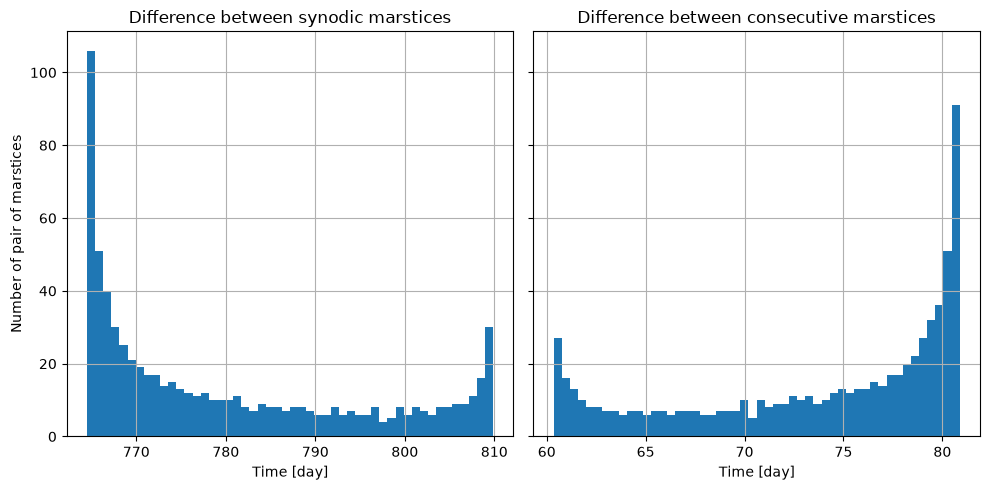

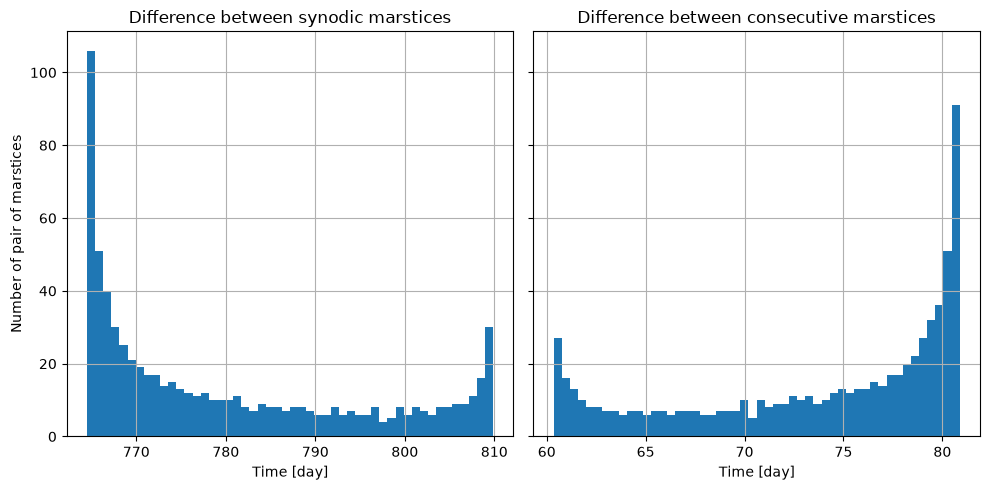

In [18]:
fig,axs = plt.subplots(1,2,figsize=(10,5),sharey=True)

ax = axs[0]
hs1 = ax.hist(delta1,bins=50)
ax.set_xlabel("Time [day]")
ax.set_ylabel("Number of pair of marstices")
ax.set_title("Difference between synodic marstices")
ax.grid()

ax = axs[1]
hs2 = ax.hist(delta2,bins=50)
ax.set_title("Difference between consecutive marstices")
ax.set_xlabel("Time [day]")
ax.grid()

fig.tight_layout()
from IPython.display import display
display(fig)


In [19]:
print(f"Periodicity of synodic marstices: {hs1[1][0]:.1f} - {hs1[1][-1]:.1f}")
print(f"Periodicity of consecutive marstices: {hs2[1][0]:.1f} - {hs2[1][-1]:.1f}")


Periodicity of synodic marstices: 764.5 - 809.9
Periodicity of consecutive marstices: 60.3 - 80.9


#### Periodicity of winter marstices

Let's extract the winter marstices:

In [20]:
winter_marstices = marstices[marstices.close_solstice]

Let's get the periodicity:

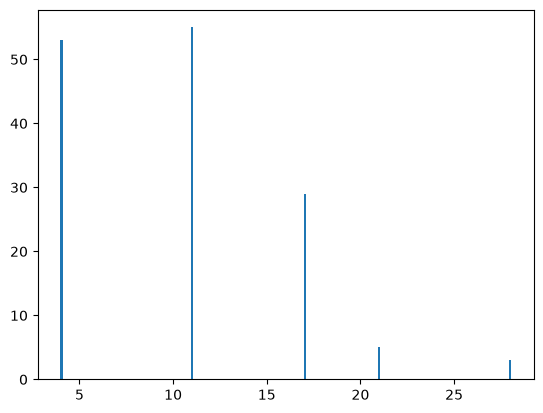

In [21]:
times = winter_marstices.jed.to_numpy()
delta = (times[1:]-times[:-1])*montu.DAY/montu.YEAR
hs = plt.hist(delta,bins=200)
plt.show()


Get the periodicities:

In [22]:
# Times
ts = (hs[1][1:]+hs[1][:-1])/2
# Frequencies
fs = hs[0]
# Times with a positive frequency
cond = fs>0
isort = fs[cond].argsort()[::-1]
Ps = ts[cond][isort]
print("Periods of winter marstices [years]: ", Ps)

Periods of winter marstices [years]:  [11.0162576   4.03507962 17.03451448 21.00656402 27.98774199]


#### Periodicity of Aldebaran conjunctions

Let's extract the Aldebaran conjunctions:

In [23]:
aldebaran_marstices = marstices[marstices.close_aldebaran]
len(aldebaran_marstices)

121

Let's get the periodicity:

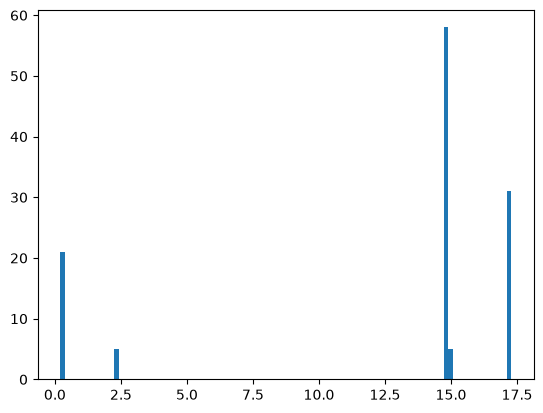

In [24]:
times = aldebaran_marstices.jed.to_numpy()
delta = (times[1:]-times[:-1])*montu.DAY/montu.YEAR
hs = plt.hist(delta,bins=100)
plt.show()


Get the periodicities:

In [25]:
# Times
ts = (hs[1][1:]+hs[1][:-1])/2
# Frequencies
fs = hs[0]
# Times with a positive frequency
cond = fs>0
isort = fs[cond].argsort()[::-1]
Ps = ts[cond][isort]
print("Periods of winter marstices [years]: ", Ps)

Periods of winter marstices [years]:  [14.80330875 17.19389575  0.28903055 14.97406496  2.33810512]


#### Periodicity of Montunctions

Let's extract the Aldebaran conjunctions:

In [26]:
len(montunctions)

24

Let's get the periodicity:

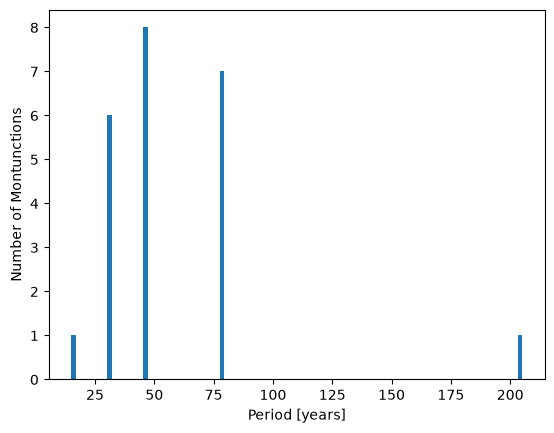

In [27]:
times = montunctions.jed.to_numpy()
delta = (times[1:]-times[:-1])*montu.DAY/montu.YEAR
hs = plt.hist(delta,bins=100)
plt.xlabel("Period [years]")
plt.ylabel("Number of Montunctions")
plt.show()


Get the periodicities:

In [28]:
# Times
ts = (hs[1][1:]+hs[1][:-1])/2
# Frequencies
fs = hs[0]
# Times with a positive frequency
cond = fs>0
isort = fs[cond].argsort()[::-1]
Ps = ts[cond][isort]
print("Periods of Montunctions [years]: ", Ps)

Periods of Montunctions [years]:  [ 46.31123293  78.61829458  31.1079098  204.04571042  15.90458667]


### Lines chart of marstices and montunctions

In [29]:
# Selection of marstices
selection = marstices.loc[:]
nmarstices = len(selection)

jed_min = (1-1e-3)*selection.jed.min()
jed_max = (1+1e-3)*selection.jed.max()

# Number of panels
npanels = 6
delta_jed = (jed_max - jed_min)/npanels

In [30]:
import datetime

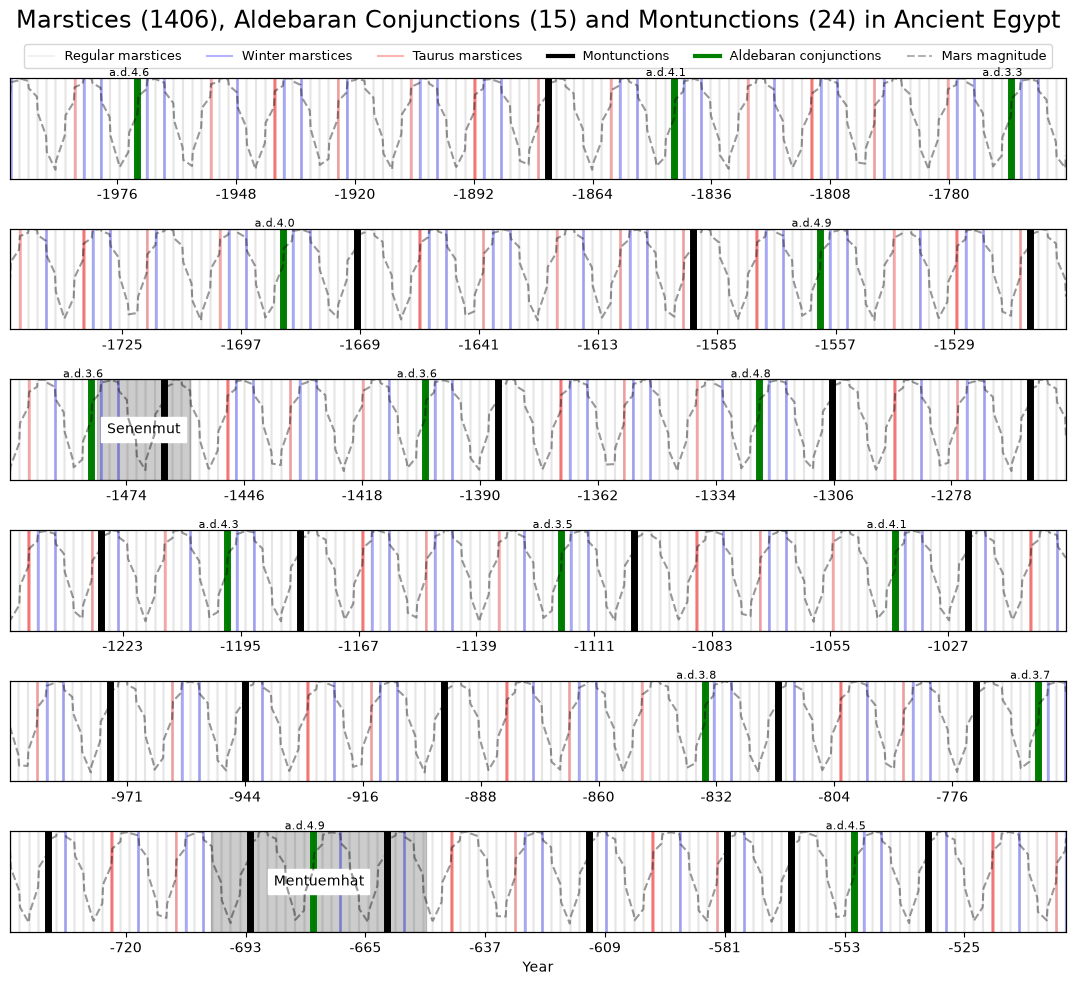

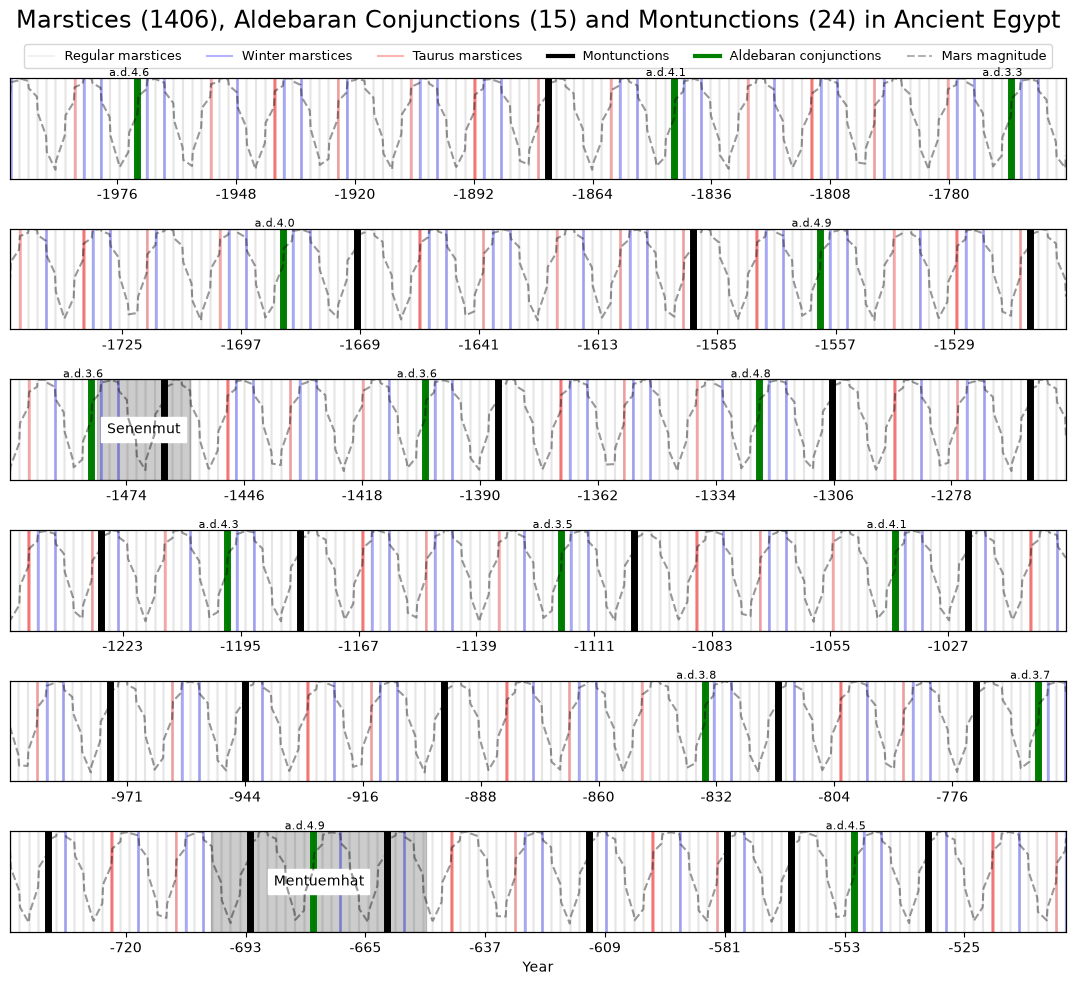

In [31]:
fig,axs = plt.subplots(npanels,1,figsize=(12,10))

axts = []
for ax in axs:
    axts += [ax.twinx()]

alpha_marst = 0.05
alpha_wmarst = 0.3
alpha_aldeb = 0.3
alpha_montu = 1
alpha_mag = 0.3

# Loop on marstices
for index in selection.index:

    # Get marstice information and location of mars
    marstice = selection.loc[index]
    mars_location = mars_marstices.loc[index]

    # Get MonTime object
    mtime = montu.Time(marstice.jed,format='jd')

    # Get panel
    i = int(np.floor((mtime.jed - jed_min)/delta_jed))
    
    # Plot line for marstices
    axs[i].axvline(mtime.jed,color='k',alpha=alpha_marst)

    # Plot line for winter marstices
    if marstice.close_solstice:
        axs[i].axvline(mtime.jed,color='b',lw=2,alpha=alpha_wmarst)

    # Plot line for aldebaran conjunctions
    if marstice.close_aldebaran:
        axs[i].axvline(mtime.jed,color='r',lw=2,alpha=alpha_aldeb)

    # Plot line for aldebaran close conjunctions
    if marstice.conj_aldebaran:
        axs[i].axvline(mtime.jed,color='g',lw=5,alpha=alpha_montu)
        
    # Plot line for montunctions
    if marstice.close_solstice and marstice.close_aldebaran:
        axs[i].axvline(mtime.jed,color='k',lw=5,alpha=alpha_montu)

# Plot distance
for i,axt in enumerate(axts):
    jed_ax_min = jed_min + i*delta_jed
    jed_ax_max = jed_ax_min + delta_jed
    cond = (marstices.jed>=jed_ax_min)&(marstices.jed<=jed_ax_max)
    #axt.plot(marstices[cond].jed,mars.df[cond].site_distance,'k',alpha=0.4)
    axt.plot(marstices[cond].jed,mars_marstices[cond].Vmag,'k--',alpha=0.4)
    
# Loop on marstices
for index in selection.index:
    # Get MonTime object
    mtime = montu.Time(marstice.jed,format='jd')

    # Get marstice information and location of mars
    marstice = selection.loc[index]
    
    # Get panel
    i = int(np.floor((mtime.jed - jed_min)/delta_jed))
    
    # Plot line for aldebaran close conjunctions
    if marstice.conj_aldebaran:
        mmin,mmax = axts[i].get_ylim()
        t = axts[i].text(mtime.jed,0.95*mmax,f"a.d.{marstice.aldebaran_angdist:.1f}",
                         ha='center',va='center',fontsize=8)

# Decoration
for i,ax in enumerate(axs):
    ax.margins(0)
    ax.get_yaxis().set_visible(False)
    jed_ax_min = jed_min + i*delta_jed
    jed_ax_max = jed_ax_min + delta_jed
    ax.set_xticks(np.linspace(jed_ax_min,jed_ax_max,10))
    
# Change xticks
for ax in axs:
    xticks = ax.get_xticks()
    xtick_labels = []
    for xt in xticks:
        mtime = montu.Time(xt,format='jd',full=True)
        xtick_labels += [f'{mtime.readable.year}']
    ax.set_xticklabels(xtick_labels)

for ax in axts:
    ax.margins(0)
    ax.set_yticks(np.arange(-2.5,0.0,0.5))
    ax.get_yaxis().set_visible(False)

# Legends 
axs[0].plot([],[],'k-',alpha=alpha_marst,label='Regular marstices')
axs[0].plot([],[],'b-',alpha=alpha_wmarst,label='Winter marstices')
axs[0].plot([],[],'r-',alpha=alpha_aldeb,label='Taurus marstices')
axs[0].plot([],[],'k-',alpha=alpha_montu,lw=3,label='Montunctions')
axs[0].plot([],[],'g-',alpha=alpha_montu,lw=3,label='Aldebaran conjunctions')
axs[0].plot([],[],'k--',alpha=alpha_mag,label='Mars magnitude')
axs[0].legend(bbox_to_anchor=(0.5,1.4),ncol=6,fontsize=9,loc='upper center')

# Other decoration
axs[-1].set_xlabel('Year')

axs[0].text(0.5,1.5,f"Marstices ({len(marstices)}), Aldebaran Conjunctions ({selection.conj_aldebaran.sum()}) and Montunctions ({len(montunctions)}) in Ancient Egypt",
            transform=axs[0].transAxes,fontsize=17,ha='center')

"""
# Spans
# Montuhotep II 
iax = 1
j1 = montu.Time('-2066-01-01').jed
j2 = montu.Time('-1957-01-01').jed
jk = (j1+j2)/2
mmin,mmax = axs[iax].get_ylim()
axs[iax].axvspan(j1,j2,color='k',alpha=0.2)
t = axs[iax].text(jk,0.0,'Montuhotep II',ha='center',va='center',fontsize=10)
t.set_bbox(dict(facecolor='white', edgecolor='white'))
""" 

# Senenmut
iax = 2
j1 = montu.Time('-1480-01-01').jed
j2 = montu.Time('-1458-01-01').jed
jmin,jmax = axs[iax].get_xlim()
j1 = max(j1,jmin)
j2 = min(j2,jmax)
jk = (j1+j2)/2
mmin,mmax = axs[iax].get_ylim()
axs[iax].axvspan(j1,j2,color='k',alpha=0.2)
t = axs[iax].text(jk,0.0,'Senenmut',ha='center',va='center',fontsize=10)
t.set_bbox(dict(facecolor='white', edgecolor='white'))

# Mentuemhat
iax = 5
j1 = montu.Time('-700-01-01').jed
j2 = montu.Time('-650-01-01').jed
jk = (j1+j2)/2
mmin,mmax = axs[iax].get_ylim()
axs[iax].axvspan(j1,j2,color='k',alpha=0.2)
t = axs[iax].text(jk,0.0,'Mentuemhat',ha='center',va='center',fontsize=10)
t.set_bbox(dict(facecolor='white', edgecolor='white'))

fig.tight_layout()
from IPython.display import display
display(fig)


Magnitude at Montunctions:

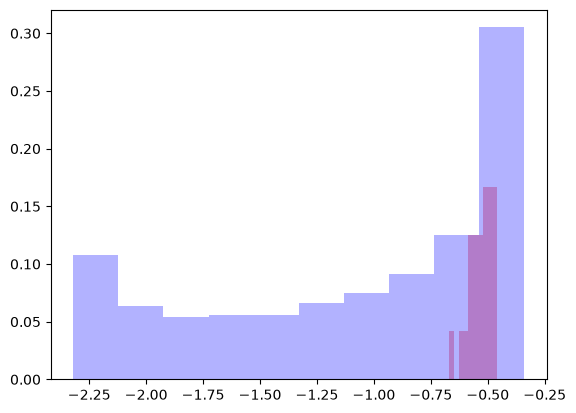

In [32]:
cond = cond_montunctions = (cond_solstices) & (cond_aldebaran)
hs = plt.hist(mars_marstices[cond].Vmag,color='r',alpha=0.3,
              weights=[1/len(mars_marstices[cond])]*len(mars_marstices[cond]))
hs = plt.hist(mars_marstices.Vmag,color='b',alpha=0.3,
              weights=[1/len(mars_marstices)]*len(mars_marstices))
plt.show()


### Montunctions visualization

Let's see one of this *montunctions* in the sky:

In [33]:
# Time of montunction
mtime_montunction = montu.Time(montunctions.iloc[-5].jed,format='jd',full=True)
t = mtime_montunction.tt

mars.reset_store()
for t in np.linspace(-50*montu.DAY,0*montu.DAY,50):
    # Get MonTime object
    mtime = mtime_montunction + t

    # Calculate Mars position and store it
    mars.where_in_sky(mtime,Tebas,store=1)
mars.tabulate_store()

Create a map of montunction:

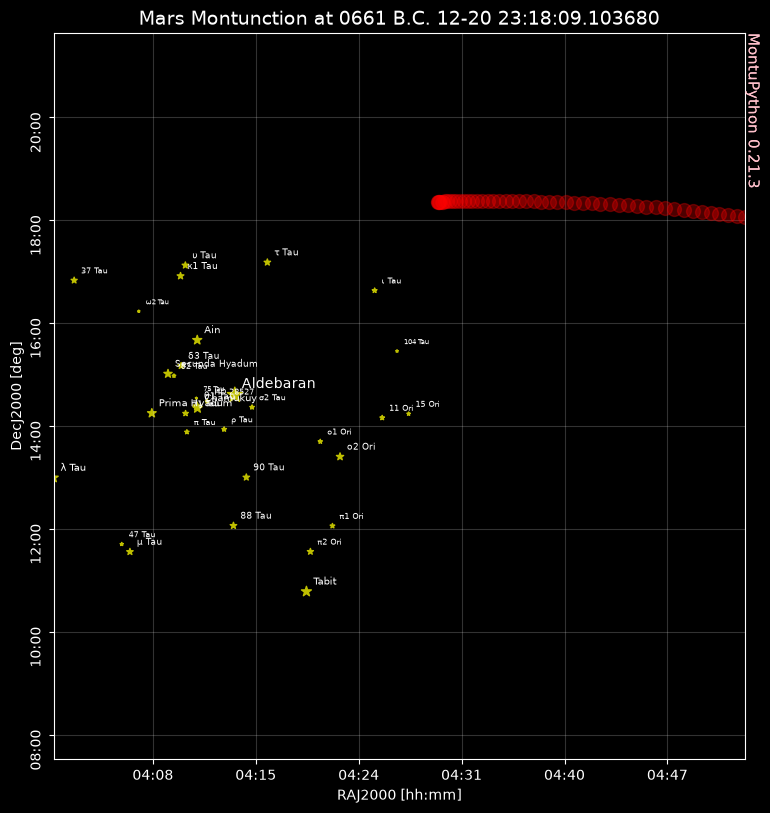

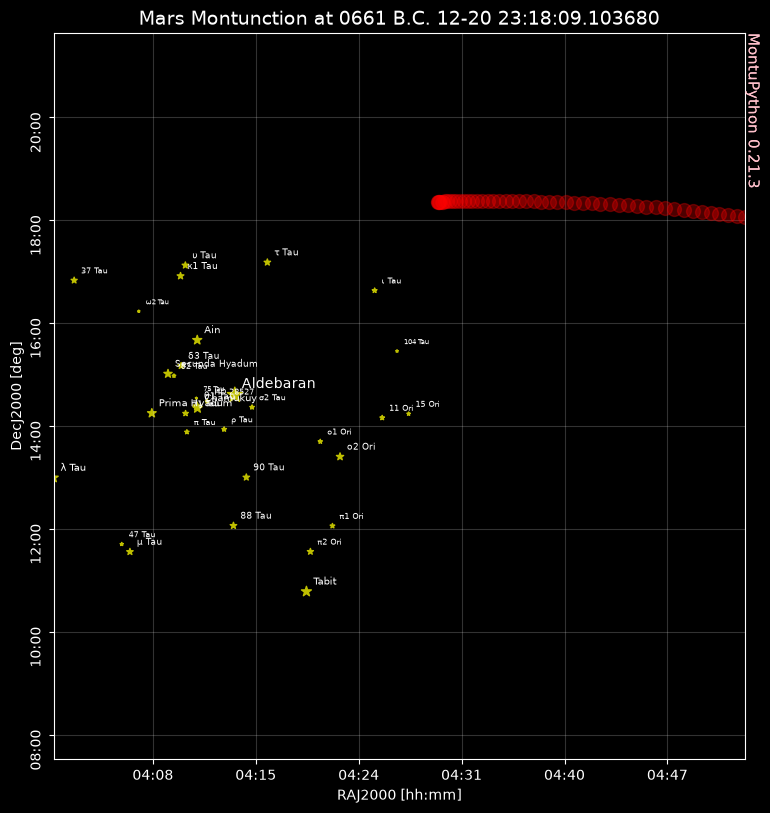

In [34]:
# Plot Hyades
hyades = allstars.get_stars_around(center=[aldebaran.data.RAJ2000,aldebaran.data.DecJ2000],radius=10,Vmag=[-1,5])
fig,ax = hyades.plot_stars(pad=0.0,labels=True,figargs=dict(figsize=(8,8)))

for index in mars.position.index:
    mars_position = mars.position.loc[index]
    ax.plot(15*mars_position.RAJ2000,mars_position.DecJ2000,'ro',ms=10,alpha=0.3)

ax.set_title(f"Mars Montunction at {mtime_montunction.readable.datespice}",fontsize=14)
montu.Util.montu_mark(ax);
from IPython.display import display
display(fig)


## Interesting montunctions

We are interested in the Montunctions happening around the date of birth or dead of Senenmut who, according to several chronologies lived between 1480bce and 1458 bce. Let's select the montunctions in this range:

In [35]:
mtime_start = montu.Time('bce1480-01-01 00:00:00.00')+(-50*montu.YEAR)
mtime_end = montu.Time('bce1480-01-01 00:00:00.00')+50*montu.YEAR

cond = (montunctions.jed>=mtime_start.jed) & (montunctions.jed<=mtime_end.jed)
print("Number of montunctions in the desired interval: ",cond.sum())

montunctions_selected = montunctions.loc[cond]
montunctions_selected

Number of montunctions in the desired interval:  2


,datepro,datemix,type,jed,closest_solstice,aldebaran_angdist,close_solstice,close_aldebaran,conj_aldebaran,montunctions
459,-1512-12-10 23:40:17.296304,-1512-12-24 23:40:40,second,1.169158e+06,8.282254,14.651087,True,True,False,True
503,-1465-12-06 03:30:47.802240,-1465-12-19 03:30:30,second,1.186319e+06,14.549713,9.723496,True,True,False,True


Let's see the montunctions:


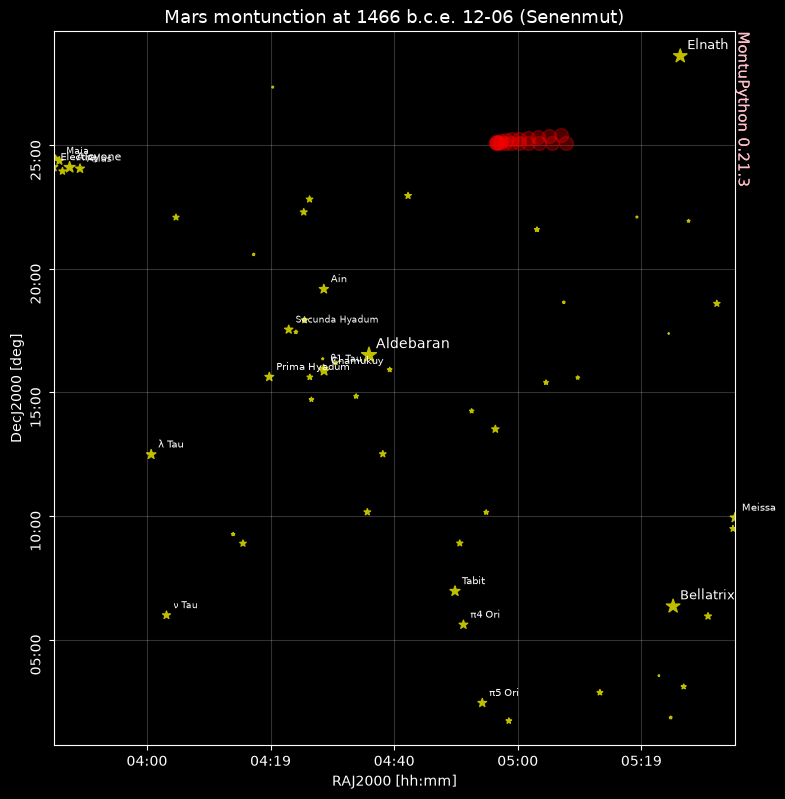

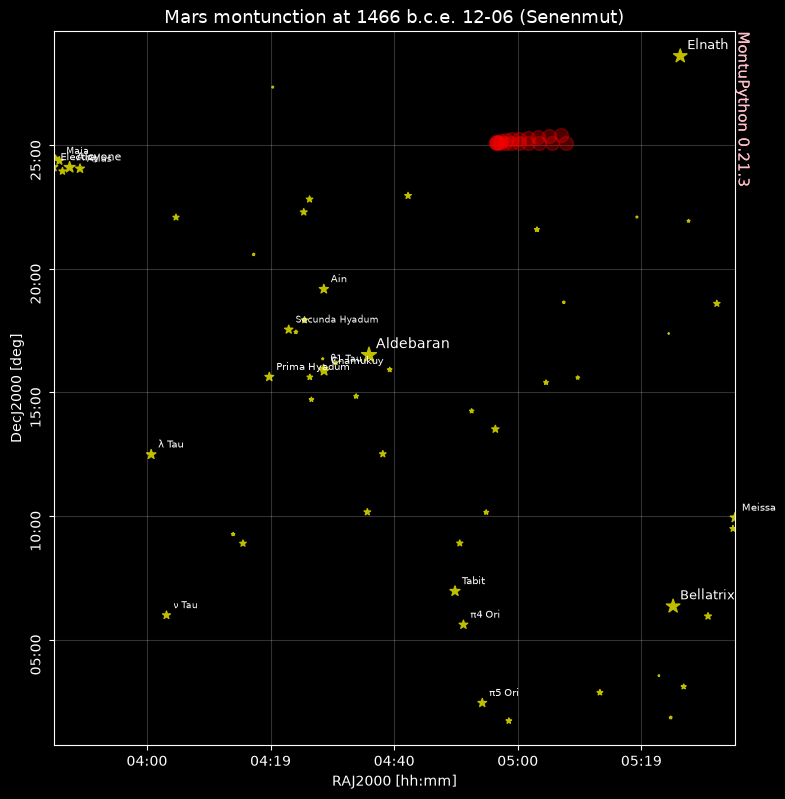

In [36]:
# Time of montunction
isel = 1
mtime_montunction = montu.Time(montunctions_selected.iloc[isel].jed,format='jd',full=True)
t = mtime_montunction.tt

mars.reset_store()
for t in np.linspace(-20*montu.DAY,20*montu.DAY,20):
    # Get MonTime object
    mtime = mtime_montunction + t

    # Calculate Mars position and store it
    mars.where_in_sky(mtime,Tebas,store=1)
mars.tabulate_store()

# Plot Hyades
hyades = allstars.get_stars_around(center=[aldebaran.data.RAJ2000,aldebaran.data.DecJ2000],radius=15,Vmag=[-1,5])
fig,ax = hyades.plot_stars(pad=0.0,labels=True,label_mag=4,figargs=dict(figsize=(8,8)))

for index in mars.position.index:
    mars_position = mars.position.loc[index]
    ax.plot(15*mars_position.RAJ2000,mars_position.DecJ2000,'ro',ms=10,alpha=0.3)

ax.set_title(f"Mars montunction at {-mtime_montunction.readable.year+1} \
b.c.e. {mtime_montunction.readable.month:02d}-{mtime_montunction.readable.day:02d} (Senenmut)",fontsize=13)
montu.Util.montu_mark(ax);
from IPython.display import display
display(fig)


We are interested in the Montunctions happening around the date of birth or dead of Mentuhotep (2119 - 2103)

In [37]:
mtime_start = montu.Time('bce600-01-01 00:00:00.00')+(-70*montu.YEAR)
mtime_end = montu.Time('bce600-01-01 00:00:00.00')+70*montu.YEAR

cond = (montunctions.jed>=mtime_start.jed) & (montunctions.jed<=mtime_end.jed)
print("Number of montunctions in the desired interval: ",cond.sum())

montunctions_selected = montunctions.loc[cond]
montunctions_selected

Number of montunctions in the desired interval:  5


,datepro,datemix,type,jed,closest_solstice,aldebaran_angdist,close_solstice,close_aldebaran,conj_aldebaran,montunctions
1257,-660-12-20 23:18:09.103680,-660-12-27 23:18:18,second,1.480354e+06,0.604677,13.079182,True,True,False,True
1301,-613-12-14 20:15:27.293760,-613-12-21 20:15:15,second,1.497514e+06,5.938564,8.667736,True,True,False,True
1331,-581-12-25 06:26:22.200016,-581-12-31 06:26:26,second,1.509212e+06,3.708349,14.680452,True,True,False,True
1345,-566-12-08 08:31:32.096640,-566-12-14 08:31:31,second,1.514674e+06,12.862503,8.097878,True,True,False,True
1375,-534-12-18 05:15:19.604160,-534-12-24 05:15:15,second,1.526372e+06,2.773414,9.781388,True,True,False,True


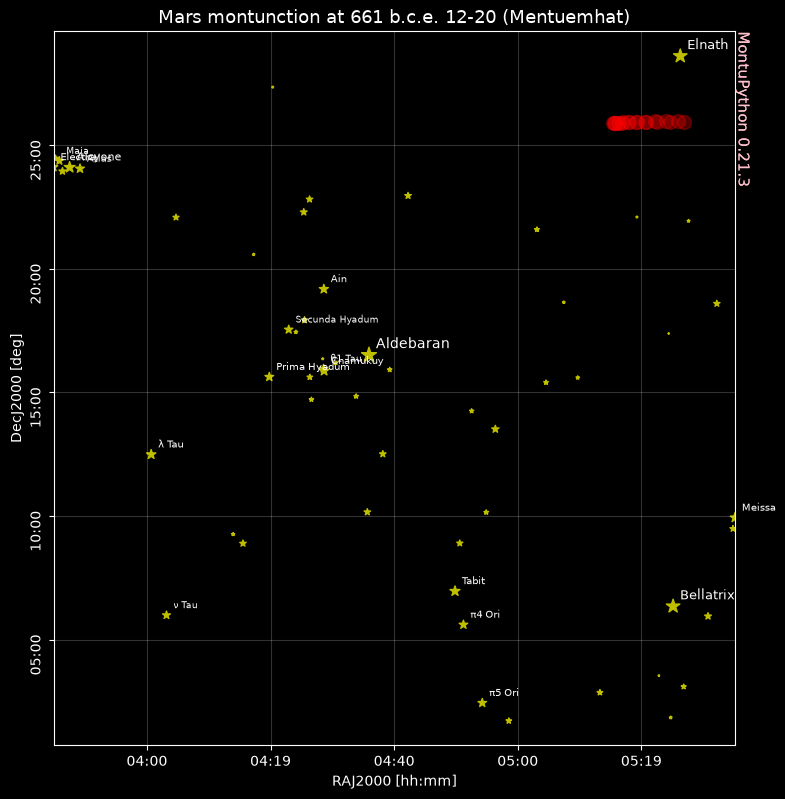

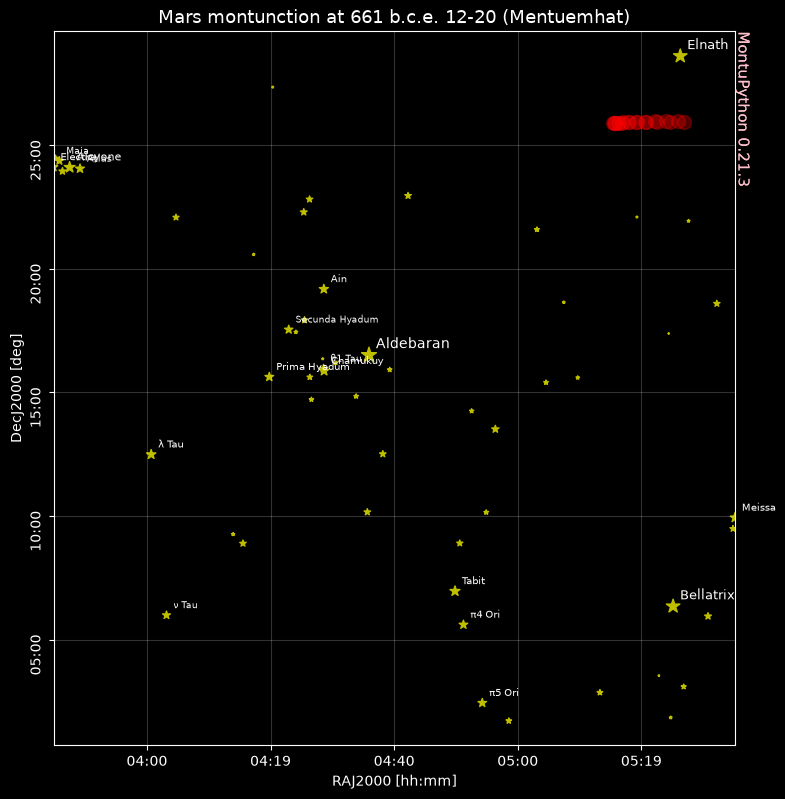

In [38]:
# Time of montunction
isel = 0
mtime_montunction = montu.Time(montunctions_selected.iloc[isel].jed,format='jd',full=True)
t = mtime_montunction.tt

mars.reset_store()
for t in np.linspace(-20*montu.DAY,20*montu.DAY,20):
    # Get MonTime object
    mtime = mtime_montunction + t

    # Calculate Mars position and store it
    mars.where_in_sky(mtime,Tebas,store=1)
mars.tabulate_store()

# Plot Hyades
hyades = allstars.get_stars_around(center=[aldebaran.data.RAJ2000,aldebaran.data.DecJ2000],radius=15,Vmag=[-1,5])
fig,ax = hyades.plot_stars(pad=0.0,labels=True,label_mag=4,figargs=dict(figsize=(8,8)))

for index in mars.position.index:
    mars_position = mars.position.loc[index]
    ax.plot(15*mars_position.RAJ2000,mars_position.DecJ2000,'ro',ms=10,alpha=0.3)

ax.set_title(f"Mars montunction at {-mtime_montunction.readable.year+1} \
b.c.e. {mtime_montunction.readable.month:02d}-{mtime_montunction.readable.day:02d} (Mentuemhat)",fontsize=13)
montu.Util.montu_mark(ax);
from IPython.display import display
display(fig)


## Conjunctions

We are interested in the Montunctions happening around the date of birth or dead of Mentuhotep (2119 - 2103)

In [39]:
mtime_start = montu.Time('bce1050-08-01 00:00:00.00')+(-1*montu.YEAR)
mtime_end = montu.Time('bce1050-08-01 00:00:00.00')+1*montu.YEAR

cond = (marstices.jed>=mtime_start.jed) & (marstices.jed<=mtime_end.jed)
print("Number of marstices in the desired interval: ",cond.sum())

marstices_selected = marstices.loc[cond]
marstices_selected

Number of marstices in the desired interval:  2


,datepro,datemix,type,jed,closest_solstice,aldebaran_angdist,close_solstice,close_aldebaran,conj_aldebaran,montunctions
892,-1048-01-05 10:51:15.998416,-1048-01-15 10:51:51,first,1.338290e+06,15.631285,124.671995,False,False,False,False
893,-1048-03-24 13:37:48.797760,-1048-04-03 13:37:37,second,1.338369e+06,94.746943,106.237353,False,False,False,False


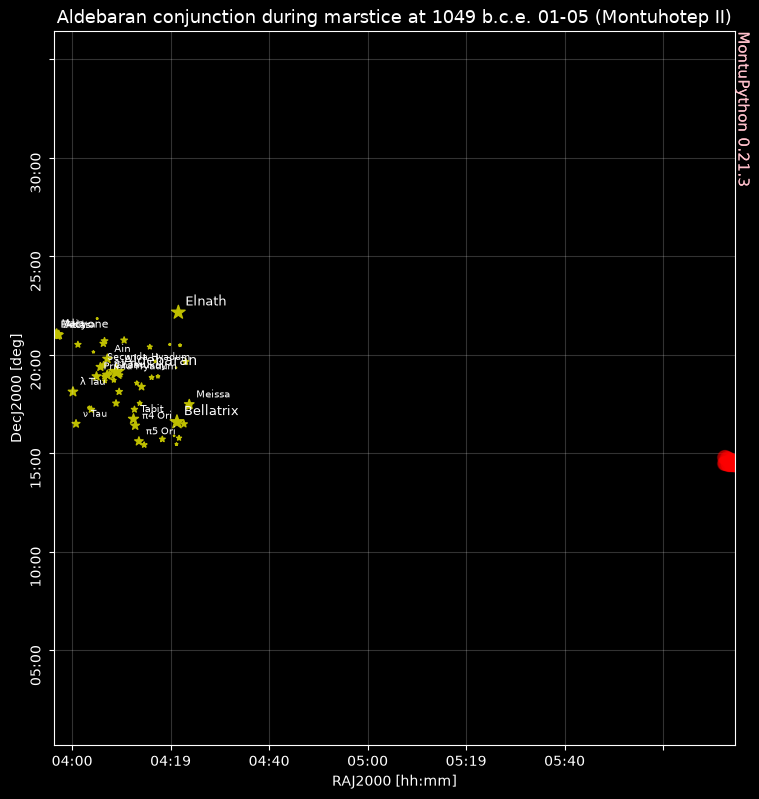

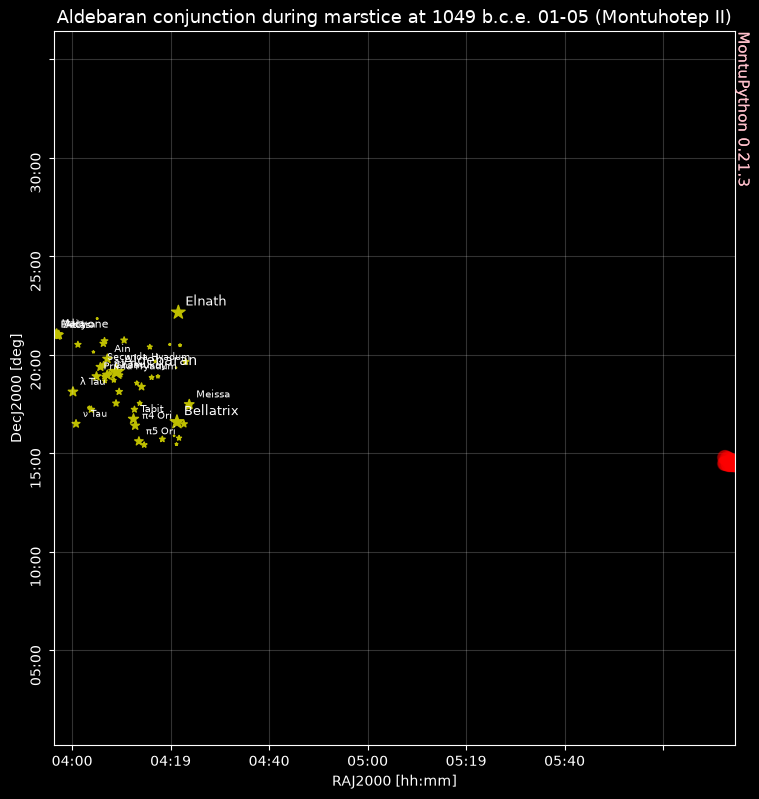

In [40]:
# Time of montunction
isel = 0
mtime_marstice = montu.Time(marstices_selected.iloc[isel].jed,format='jd',full=True)
t = mtime_marstice.tt

mars.reset_store()
for t in np.linspace(-20*montu.DAY,20*montu.DAY,50):
    # Get MonTime object
    mtime = mtime_marstice + t

    # Calculate Mars position and store it
    mars.where_in_sky(mtime,Tebas,store=1)
mars.tabulate_store()

# Plot Hyades
hyades = allstars.get_stars_around(center=[aldebaran.data.RAJ2000,aldebaran.data.DecJ2000],radius=15,Vmag=[-1,5])
fig,ax = hyades.plot_stars(pad=0.0,labels=True,label_mag=4,figargs=dict(figsize=(8,8)))

for index in mars.position.index:
    mars_position = mars.position.loc[index]
    ax.plot(15*mars_position.RAJ2000,mars_position.DecJ2000,'ro',ms=10,alpha=0.3)

ax.set_title(f"Aldebaran conjunction during marstice at {-mtime_marstice.readable.year+1} \
b.c.e. {mtime_marstice.readable.month:02d}-{mtime_marstice.readable.day:02d} (Montuhotep II)",fontsize=13)
montu.Util.montu_mark(ax);
from IPython.display import display
display(fig)


In [41]:
mtime_start = montu.Time('bce1580-08-01 00:00:00.00')+(-100*montu.YEAR)
mtime_end = montu.Time('bce1580-08-01 00:00:00.00')+100*montu.YEAR

cond = (marstices.jed>=mtime_start.jed) & (marstices.jed<=mtime_end.jed) & (marstices.aldebaran_angdist<=max_aldebaran_conjunc)
print("Number of marstices in the desired interval: ",cond.sum())

marstices_selected = marstices.loc[cond]
marstices_selected

Number of marstices in the desired interval:  2


,datepro,datemix,type,jed,closest_solstice,aldebaran_angdist,close_solstice,close_aldebaran,conj_aldebaran,montunctions
412,-1561-08-22 22:36:39.098880,-1561-09-05 22:36:36,first,1.151150e+06,119.410078,4.893175,False,True,True,False
486,-1482-08-26 07:38:10.302720,-1482-09-08 07:38:38,first,1.180008e+06,116.239785,3.616589,False,True,True,False


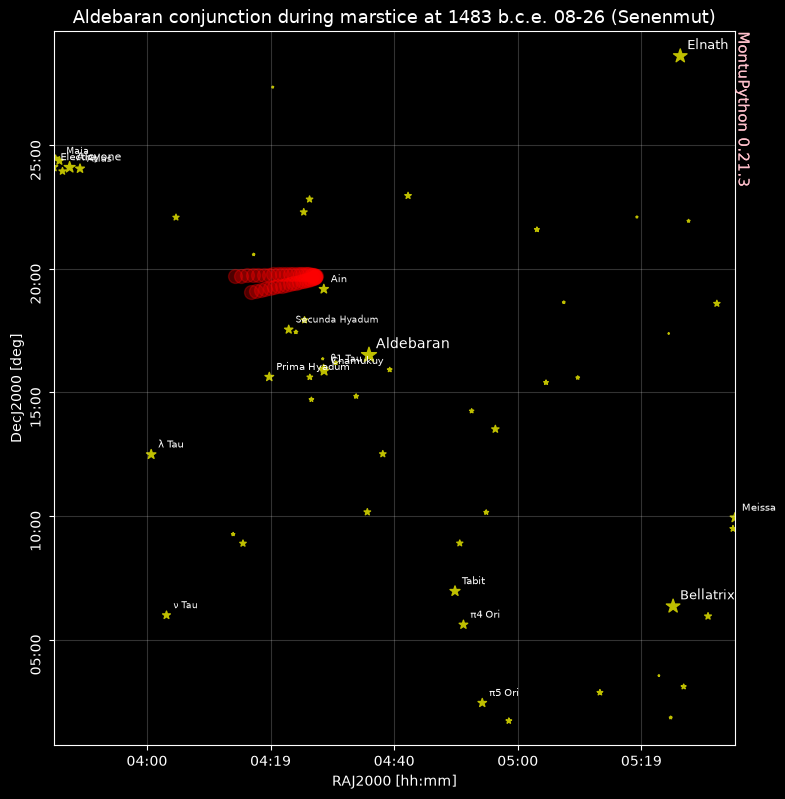

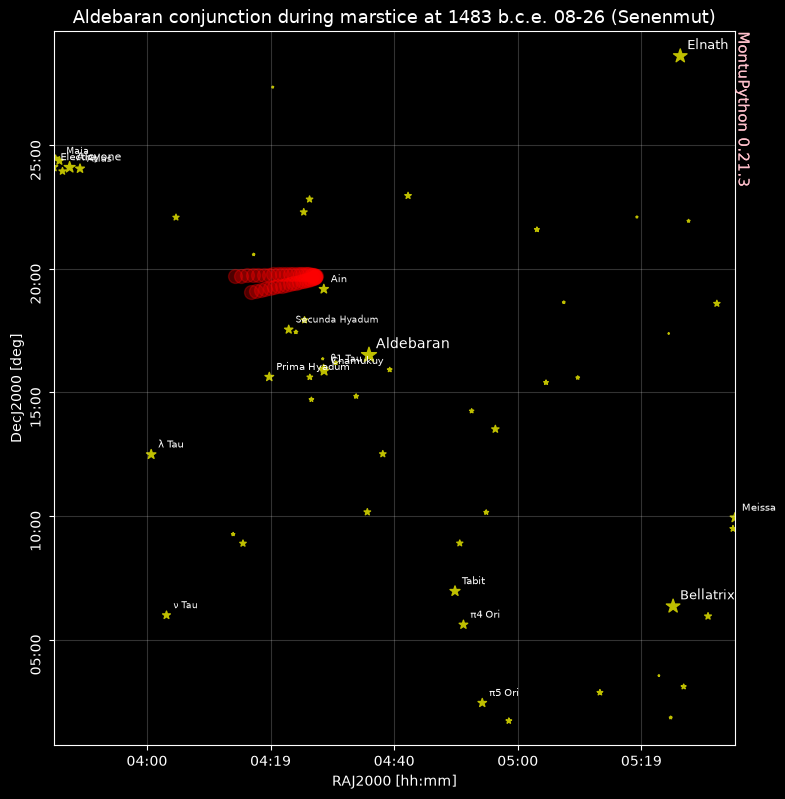

In [42]:
# Time of montunction
isel = 1
mtime_marstice = montu.Time(marstices_selected.iloc[isel].jed,format='jd',full=True)
t = mtime_marstice.tt

mars.reset_store()
for t in np.linspace(-20*montu.DAY,20*montu.DAY,50):
    # Get MonTime object
    mtime = mtime_marstice + t

    # Calculate Mars position and store it
    mars.where_in_sky(mtime,Tebas,store=1)
mars.tabulate_store()

# Plot Hyades
hyades = allstars.get_stars_around(center=[aldebaran.data.RAJ2000,aldebaran.data.DecJ2000],radius=15,Vmag=[-1,5])
fig,ax = hyades.plot_stars(pad=0.0,labels=True,label_mag=4,figargs=dict(figsize=(8,8)))

for index in mars.position.index:
    mars_position = mars.position.loc[index]
    ax.plot(15*mars_position.RAJ2000,mars_position.DecJ2000,'ro',ms=10,alpha=0.3)

ax.set_title(f"Aldebaran conjunction during marstice at {-mtime_marstice.readable.year+1} \
b.c.e. {mtime_marstice.readable.month:02d}-{mtime_marstice.readable.day:02d} (Senenmut)",fontsize=13)
montu.Util.montu_mark(ax);
from IPython.display import display
display(fig)


---
*Powered by MontuPython*. For more examples see [MontuPython GitHub repo](https://github.com/seap-udea/MontuPython/tree/main/examples).

Jorge I. Zuluaga © 2023-present